# Исследовательский анализ данных Яндекс Афиши

## Цели и задачи проекта

**Цель**: Выявить инсайты об изменении пользовательских предпочтений в осенний период и проверить статистические гипотезы о различиях в поведении пользователей мобильных и стационарных устройств.

**Задачи:**
- Загрузка данных и знакомство с ними;
- Предобработка данных и подготовка их к исследованию;
    - Проверька данных на пропуски;
    - Изучиние значений в ключевых столбцах: категориальне и количественные значения;
    - Проверка на явные и неявные дубликаты;
    - Преобразование типов данных;
    - Создание несколько новых столбцов;  
- Исследовательский анализ данных;
    - Анализ распределения заказов по сегментам и их сезонные изменения;
    - Анализ осенней активности пользователей;
    - Анализ популярных событий и партнёров;
- Статистический анализ данных;
- Общий вывод и рекомендации;

## Описание данных

Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 
- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
-`created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например `mobile` для мобильных устройств, `desktop` для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.
- `days_since_prev`- количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.


Датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:
- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

Датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (`kzt`).

## Содержимое проекта

Основные шаги проекта:

**Шаг 1. Загрузка и первичный обзор**
- Импорт библиотек и чтение файлов.
- Изучение структуры таблиц и типов данных.

**Шаг 2. Предобработка данных**
- Обработка пропусков и аномалий (фильтрация по 99-му процентилю).
- Удаление дубликатов.
- Конвертация валюты: создание столбца revenue_rub.
- Добавление признаков: расчет цены одного билета, выделение месяца и сезона.

**Шаг 3. Исследовательский анализ данных**

    3.1. Сезонность: сравнение долей заказов по категориям и устройствам (лето vs осень).
    3.2. Активность: расчет DAU, среднего чека и числа заказов по дням.
    3.3. География и партнеры: анализ самых прибыльных регионов и эффективных площадок.

**Шаг 4. Проверка статистических гипотез**
- **Гипотеза №1:** Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
- **Гипотеза №2:** Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
- Выбор тестов, проверка условий применимости и расчет p-value.

**Шаг 5. Общий вывод и рекомендации**
- Итоговое резюме по ключевым метрикам и подтвержденным гипотезам.


## Загрузка данных и знакомство с ними


In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')

In [3]:
# Выводим первые строки датафрейма на экран
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет `final_tickets_orders_df.csv` содержит 290849 строки и 13 столбца и включает информацию информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. В целом структура данных соответствует описанию, пропусков в данных нет, кроме столбца `days_since_prev`.  
Столбцы с датой имеют не првильный тип данных - `object`, нужно будет преобразовать в тип данных даты. 

In [5]:
events = pd.read_csv('/datasets/final_tickets_events_df.csv')

In [6]:
# Выводим первые строки датафрейма на экран
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
# Выводим информацию о датафрейме
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датасет `final_tickets_events_df.csv` содержит 22427 строки и 11 столбца и включает информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. В целом структура данных соответствует описанию, пропусков в данных нет.  

In [8]:
rates = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [9]:
# Выводим первые строки датафрейма на экран
rates.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
# Выводим информацию о датафрейме
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет `final_tickets_tenge_df.csv` содержит 357 строки и 4 столбца и содержит информацию о курсе тенге к российскому рублю за 2024 год. Структура данных соответствует описанию, пропусков в данных нет.  

##  Предобработка данных и подготовка их к исследованию

Для удобства лучше сначала объединим заказы с информацией о мероприятиях.

In [11]:
df = orders.merge(events, on='event_id', how='inner')

### Проверяем данные на пропуски

In [12]:
# Количество пропусков в датасете
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

Пропуски в `days_since_prev` (21913 значений) - это не ошибка, а особенность данных. Этот столбец считает дни с предыдущей покупки. Если у пользователя это самый первый заказ в истории, то предыдущего события не существует. Оставим их как NaN.

### Изучаем значения в ключевых столбцах

#### Категориальные значения

In [13]:
# Проверим основные категории
categorical_cols = ['currency_code', 'device_type_canonical', 'event_type_main', 'cinema_circuit']

for col in categorical_cols:
    print(f"Уникальные значения для {col}:")
    print(df[col].unique())
    print('-' * 30)

# Приведем текстовые поля к нижнему регистру на всякий случай
df['event_name'] = df['event_name'].str.lower().str.strip()

Уникальные значения для currency_code:
['rub' 'kzt']
------------------------------
Уникальные значения для device_type_canonical:
['mobile' 'desktop']
------------------------------
Уникальные значения для event_type_main:
['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']
------------------------------
Уникальные значения для cinema_circuit:
['нет' 'Другое' 'КиноСити' 'Киномакс' 'Москино' 'ЦентрФильм']
------------------------------


#### Количественные значения

In [14]:
# Статистика для рублей
print("Статистика выручки (RUB):")
display(df[df['currency_code'] == 'rub'][['revenue', 'tickets_count']].describe())

# Статистика для тенге
print("\nСтатистика выручки (KZT):")
display(df[df['currency_code'] == 'kzt'][['revenue', 'tickets_count']].describe())

Статистика выручки (RUB):


,revenue,tickets_count
count,285542.000000,285542.000000
mean,548.013929,2.754159
std,871.750181,1.171575
min,-90.760000,1.000000
25%,114.170000,2.000000
50%,346.630000,3.000000
75%,793.320000,4.000000
max,81174.540000,57.000000



Статистика выручки (KZT):


,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
max,26425.860000,6.000000


In [15]:
# Находим количество строк с нулевой выручкой
zero_revenue = df[df['revenue'] == 0]
zero_count = len(zero_revenue)
total_count = len(df)
zero_share = (zero_count / total_count) * 100

print(f"Количество заказов с нулевой выручкой: {zero_count}")
print(f"Доля таких заказов: {zero_share:.2f}%")

Количество заказов с нулевой выручкой: 5526
Доля таких заказов: 1.90%


In [16]:
# Посмотрим, есть ли среди них заказы с билетами (явная ошибка)
error_orders = zero_revenue[zero_revenue['tickets_count'] > 0]
print(f"Заказов, где билетов > 0, а выручка 0: {len(error_orders)}")

# Удаляем их
df = df[df['revenue'] > 0]

Заказов, где билетов > 0, а выручка 0: 5526


При первичном анализе столбца `revenue` были обнаружены следующие аномалии:
- Отрицательные значения: Минимальная выручка в рублях составила -90.76. Это может указывать на возвраты или ошибки системы, которые не должны учитываться в анализе продаж.
- Нулевая выручка при наличии билетов: Около 1.90% заказов (5526 строк) имеют нулевую стоимость при tickets_count > 0. Это явный технический сбой, который может исказить расчет среднего чека.
- Выбросы (хвосты): В обеих валютах наблюдаются длинные хвосты распределения. В RUB максимальное значение (81 174) более чем в 140 раз превышает среднее (548).

**Решение по обработке:**
- Фильтрация по 99-му процентилю: Чтобы сосредоточиться на обычных пользователях, мы отсечем по 1% самых дорогих заказов для каждой валюты.
- Очистка от нулей и отрицательных значений: Все заказы с revenue <= 0 удалены как нерепрезентативные.

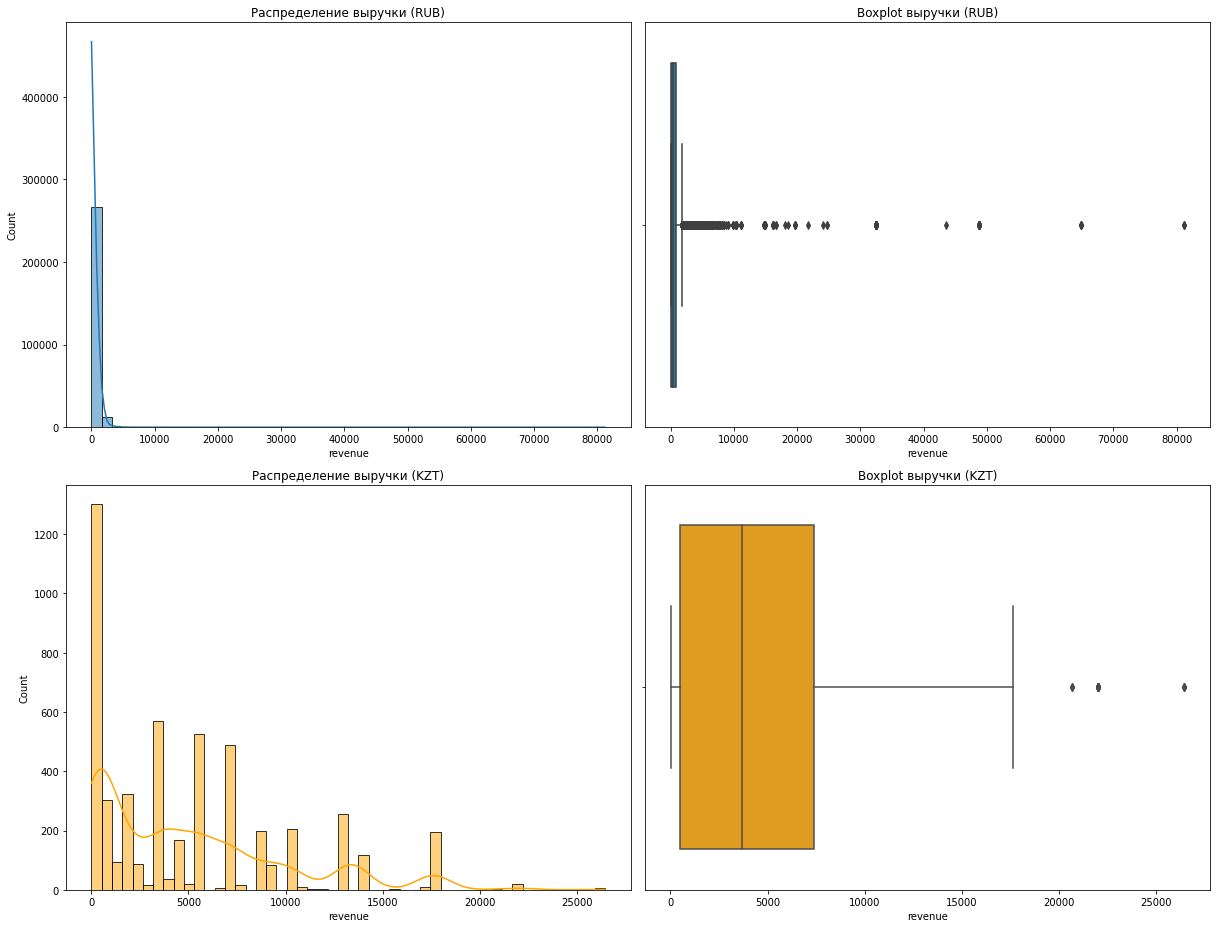

In [17]:
# Создаем сетку графиков
fig, axes = plt.subplots(2, 2, figsize=(17, 13))

# RUB Revenue
sns.histplot(df[df['currency_code'] == 'rub']['revenue'], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Распределение выручки (RUB)')

sns.boxplot(x=df[df['currency_code'] == 'rub']['revenue'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot выручки (RUB)')

# KZT Revenue
sns.histplot(df[df['currency_code'] == 'kzt']['revenue'], bins=50, ax=axes[1, 0], kde=True, color='orange')
axes[1, 0].set_title('Распределение выручки (KZT)')

sns.boxplot(x=df[df['currency_code'] == 'kzt']['revenue'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Boxplot выручки (KZT)')

plt.tight_layout()
plt.show()

Мы увидели хвосты на графиках, обрежем их. Рассчитаем порог для каждой валюты отдельно.

In [18]:
# Рассчитываем пороги
limit_rub = df[df['currency_code'] == 'rub']['revenue'].quantile(0.99)
limit_kzt = df[df['currency_code'] == 'kzt']['revenue'].quantile(0.99)

print(f"99-й процентиль для RUB: {limit_rub:.2f}")
print(f"99-й процентиль для KZT: {limit_kzt:.2f}")

# Отфильтровываем выбросы
df = df[
    ((df['currency_code'] == 'rub') & (df['revenue'] <= limit_rub)) |
    ((df['currency_code'] == 'kzt') & (df['revenue'] <= limit_kzt))
]

99-й процентиль для RUB: 2574.32
99-й процентиль для KZT: 17617.24


Анализ количества билетов не зависит от валюты, поэтому здесь мы можем смотреть на весь датасет сразу.

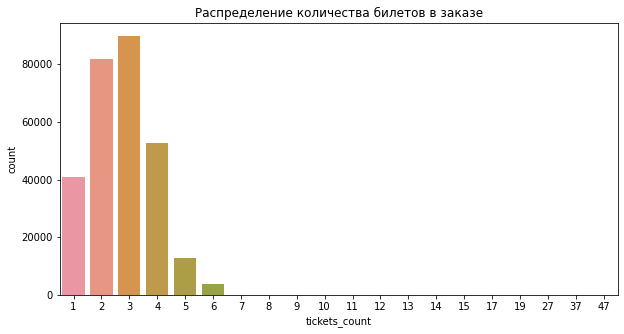

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(x='tickets_count', data=df)
plt.title('Распределение количества билетов в заказе')
plt.show()

In [20]:
# Посмотрим на частоту встречаемости разного количества билетов
print(df['tickets_count'].value_counts().sort_index().tail(10))

# Выделим заказы, где билетов больше, чем у 99% пользователей
ticket_limit = df['tickets_count'].quantile(0.99)
print(f"99-й процентиль по количеству билетов: {ticket_limit}")

11    13
12     3
13     7
14     4
15     2
17     4
19     4
27     2
37     1
47     1
Name: tickets_count, dtype: int64
99-й процентиль по количеству билетов: 6.0


In [21]:
# Изучим аномальные строки (например, всё, что выше 20 билетов)
anomaly_tickets = df[df['tickets_count'] > 20]
display(anomaly_tickets.head(10))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
183472,5190682,3ee7dc2e115847f,2024-10-06,2024-10-06 13:08:42,575780,нет,0,rub,desktop,328.49,...,eaad35f5-f733-4ab1-a671-e7e86b2748c7,спорт,спорт,№4871,Озернинский край,Лесоярич,51,3665,"Детская театральная студия ""Воспоминание"" Инко...","ш. Кочубея, д. 3/5"
183473,5190653,3ee7dc2e115847f,2024-10-06,2024-10-06 13:06:40,575780,нет,0,rub,desktop,328.49,...,eaad35f5-f733-4ab1-a671-e7e86b2748c7,спорт,спорт,№4871,Озернинский край,Лесоярич,51,3665,"Детская театральная студия ""Воспоминание"" Инко...","ш. Кочубея, д. 3/5"
243344,5338292,18e9aead0a393e7,2024-09-09,2024-09-09 10:03:45,561027,нет,12,rub,desktop,640.41,...,a8f27570-50ca-4ff2-9550-8a5493a335a6,спорт,спорт,№4870,Чистогорская область,Леснойск,968,2805,"Центр культурного наследия ""Заряд"" и партнеры","ш. Пугачева, д. 9/7 к. 39"
275566,8151843,7eb4fc207ecc10f,2024-09-17,2024-09-17 15:41:39,564789,нет,0,rub,desktop,1147.67,...,f840fd65-612b-448d-8483-e12d263a013d,спортивное мероприятие,спорт,№1531,Медовская область,Радужсвет,47,2157,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"


- 99-й процентиль равен 6.0. Это значит, что 99% всех заказов — это покупка от 1 до 6 билетов. Всё, что выше — это экстремально редкие случаи (всего 1% данных).

- Строки 86350 и 86353 показывают выручку в 328.49 руб. за большое количество билетов (судя по value_counts). Это цена в 15-20 рублей за билет, звучит нереалистично для коммерческого сервиса.

Скорее всего это либо перекупщики, либо групповые заявки, которые исказят нам всю статистику по обычным людям. Принято решение отфильтровать эти строки. 

In [22]:
df = df[(df['tickets_count'] <= ticket_limit)]

### Проверяем явные и неявные дубликаты

In [23]:
# Явные дубликаты
print(f"Явных дубликатов: {df.duplicated().sum()}")

Явных дубликатов: 0


In [24]:
# Определяем колонки для поиска неявных повторов (без учета ID заказа)
booking_columns = ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']

# Считаем количество таких строк
implicit_duplicates_count = df.duplicated(subset=booking_columns).sum()
print(f"Найдено неявных дубликатов бронирования: {implicit_duplicates_count}")

# Посмотрим на примеры таких строк
display(df[df.duplicated(subset=booking_columns, keep=False)].sort_values(by='created_ts_msk').head(10))

Найдено неявных дубликатов бронирования: 41


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
178432,8548070,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
178431,8548041,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:50,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
178436,8547867,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
178429,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
178428,8547983,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
178433,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
178426,8547809,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,25a26bf3-cb70-4f37-a7f0-c97cc065d414,спектакль,театр,№1858,Каменевский регион,Глиногорск,213,4017,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827"
221797,8248268,8f95286aa5fd8d7,2024-06-20,2024-06-20 10:57:19,244875,нет,0,rub,mobile,15.73,...,61f8b9bd-a66f-4cd9-ae10-a0e62e923476,выставка,другое,№3906,Каменноозёрный край,Ордакент,12,2492,"Кинофестиваль ""Хранитель"" Инкорпорэйтед","пр. Балтийский, д. 8 к. 51"
221798,8248210,8f95286aa5fd8d7,2024-06-20,2024-06-20 10:57:19,244875,нет,0,rub,mobile,15.73,...,61f8b9bd-a66f-4cd9-ae10-a0e62e923476,выставка,другое,№3906,Каменноозёрный край,Ордакент,12,2492,"Кинофестиваль ""Хранитель"" Инкорпорэйтед","пр. Балтийский, д. 8 к. 51"
156519,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76,3094,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"


Эти 41 строки — это не реальные продажи, а технический шум. 

- Они завышают `tickets_count` (будто продано больше билетов, чем на самом деле).
- Они искажают выручку.
- Они мешают правильному анализу поведения пользователя, будет казаться, что он очень активен, хотя он просто столкнулся с ошибкой сайта.


Принято решение удалить эти строки, оставляя только одну (первую) запись о каждом таком событии.

In [25]:
# Удаляем неявные дубликаты (оставляем только первое вхождение)
df = df.drop_duplicates(subset=booking_columns, keep='first')

# Проверяем, сколько строк осталось
print(f"Размер датасета после очистки от дубликатов и нулей: {len(df)}")

Размер датасета после очистки от дубликатов и нулей: 281664


**Вывод по дубликатам:**
- Явных дубликатов не обнаружено.

- Выявлено 41 неявное дублирование (одинаковый пользователь, время до секунды, мероприятие и количество билетов). Оставлено только первое вхождение каждого такого заказа.

### Преобразования типов данных

In [26]:
# Переводим временные столбцы в datetime
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
rates['data'] = pd.to_datetime(rates['data'])

# Оптимизируем память
df['tickets_count'] = df['tickets_count'].astype('int16')

### Создание новых столбцов

Приведим выручку с заказа к единой валюте — российскому рублю. Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю `final_tickets_tenge_df.csv` за 2024 год. Значения в рублях представлены для 100 тенге.

In [27]:
# Присоединяем курсы валют к основному датафрейму
df = df.merge(rates[['data', 'curs']], left_on='created_dt_msk', right_on='data', how='left')

# Удаляем лишний столбец 'data', так как он дублирует 'created_dt_msk'
df = df.drop(columns=['data'])

In [28]:
# Функция для перевода в рубли
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    else:
        return row['revenue'] * (row['curs'] / 100)

# Создаем столбец с выручкой в рублях
df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

In [29]:
# Проверим, нет ли пропусков
print(f"Пропусков в revenue_rub: {df['revenue_rub'].isna().sum()}")

Пропусков в revenue_rub: 0


In [30]:
# Считаем выручку с одного билета
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

Для анализа сезонности продаж создадим временные признаки.

In [31]:
# Извлекаем месяц
df['month'] = df['created_dt_msk'].dt.month

In [32]:
# Разделение на сезоны. Функция
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

# Создаем столбец с сезоном
df['season'] = df['month'].apply(get_season)

## Промежуточные выводы по этапу предобработки

В ходе подготовки данных была проведена комплексная работа по предобработке датасета. Основные результаты:

**Объединение и очистка от пропусков:** Данные о заказах были объединены со справочником мероприятий. Пропуски в `days_since_prev` оставлены без изменений, так как они обозначают первую покупку пользователя.

**Обработка аномалий и ошибок:**

- Исключены заказы с нулевой и отрицательной выручкой (около 1.9% данных), которые являлись техническими ошибками или несостоявшимися транзакциями.

- Проведена фильтрация по 99-му процентилю: удалены аномально дорогие заказы и заказы с количеством билетов более 6 штук. Это позволило очистить данные от шума.

**Борьба с дубликатами:** Выявлено и удалено 41 неявное дублирование (повторные бронирования в ту же секунду).

**Преобразование типов:** Временные столбцы переведены в формат `datetime`.

**Унификация валюты:** Создан столбец `revenue_rub`. Все расчеты в тенге конвертированы в рубли по ежедневному курсу.

**Добавлены метрики:** рассчитна стоимость одного билета (`one_ticket_revenue_rub`), выделены месяцы и сезоны совершения покупок.

**Итог:** После всех этапов очистки размер датасета составил 281 664 строки (потеря составила около 3%). Данные стали финансово сопоставимыми и полностью готовыми к проверке гипотез.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

Для каждого месяца найдем количество заказов и визуализируем результаты.

In [33]:
# Проверяем распределение данных по значениям в столбце month
print(f'Распределение данных по значениям столбца month:')
print(df['month'].value_counts())
print(f'\nДоля распределения:')
print(df['month'].value_counts(normalize=True))

Распределение данных по значениям столбца month:
10    98940
9     68851
8     43137
7     37853
6     32883
Name: month, dtype: int64

Доля распределения:
10    0.351270
9     0.244444
8     0.153151
7     0.134391
6     0.116745
Name: month, dtype: float64


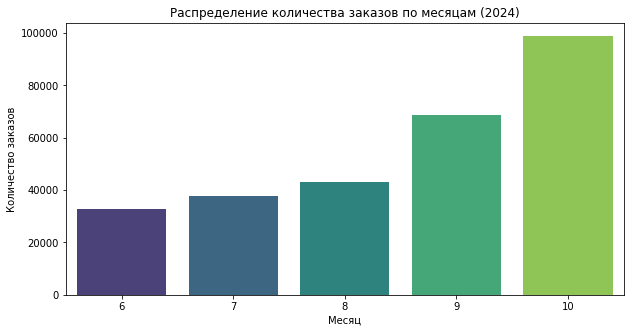

In [34]:
monthly_orders = df.groupby('month')['order_id'].count()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_orders.index, y=monthly_orders.values, palette='viridis')
plt.title('Распределение количества заказов по месяцам (2024)')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

Можем заметить, что в осенние месяцы это ~60% от всех заказов за 5 месяцев. 

Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу. 

In [35]:
seasonal_stats_results = {}
analysis_params = [
    ('event_type_main', 'типам мероприятий'),
    ('device_type_canonical', 'типам устройств'),
    ('age_limit', 'возрастному рейтингу')
]

# Фильтруем данные
seasonal_data = df[df['season'].isin(['лето', 'осень'])]

for col, title in analysis_params:
    pivot = seasonal_data.groupby([col, 'season'])['order_id'].count().unstack(level='season').fillna(0)
    pivot_pct = (pivot.div(pivot.sum(axis=0), axis=1) * 100).round(2)    
    pivot_pct['Изменение (п.п.)'] = pivot_pct['осень'] - pivot_pct['лето']
    seasonal_stats_results[title] = pivot_pct
    print(f"\nТаблица: Распределение заказов по {title} (%)")
    display(pivot_pct.sort_values(by='осень', ascending=False))


Таблица: Распределение заказов по типам мероприятий (%)


season,лето,осень,Изменение (п.п.)
event_type_main,,,
концерты,43.89,37.38,-6.51
театр,20.80,25.45,4.65
другое,24.95,19.43,-5.52
спорт,2.42,11.18,8.76
стендап,5.57,4.13,-1.44
выставки,2.11,1.43,-0.68
ёлки,0.24,1.01,0.77



Таблица: Распределение заказов по типам устройств (%)


season,лето,осень,Изменение (п.п.)
device_type_canonical,,,
mobile,80.9,79.62,-1.28
desktop,19.1,20.38,1.28



Таблица: Распределение заказов по возрастному рейтингу (%)


season,лето,осень,Изменение (п.п.)
age_limit,,,
16,28.44,26.34,-2.10
0,18.13,23.40,5.27
12,21.26,22.18,0.92
6,18.34,17.65,-0.69
18,13.84,10.43,-3.41


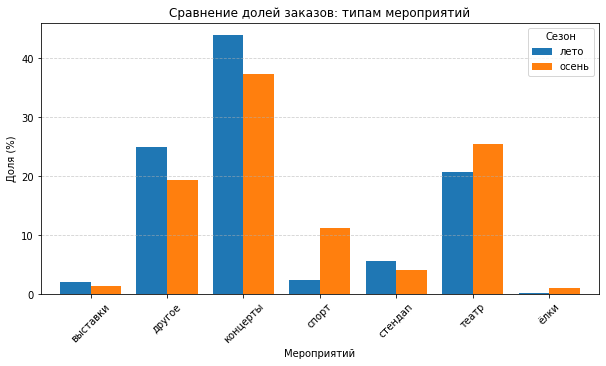

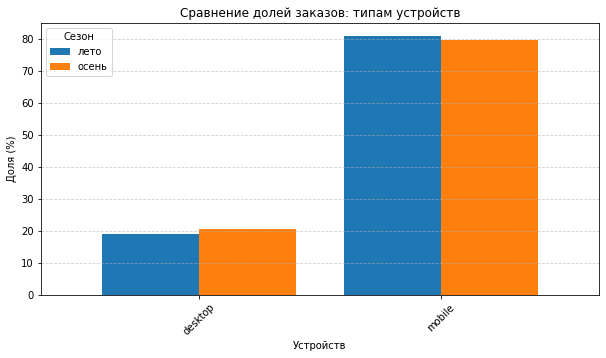

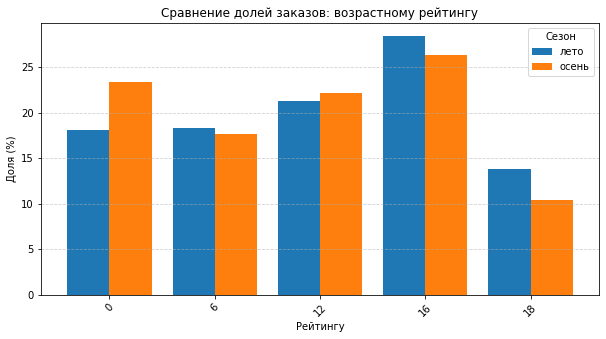

In [36]:
for title, data in seasonal_stats_results.items():
    data[['лето', 'осень']].plot(kind='bar', figsize=(10, 5), width=0.8, color=['#1f77b4', '#ff7f0e'])
    plt.title(f'Сравнение долей заказов: {title}')
    plt.ylabel('Доля (%)')
    plt.xlabel(title.split()[-1].capitalize())
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title='Сезон')
    
    plt.show()

Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.

In [37]:
ticket_price_change = df[df['season'].isin(['лето', 'осень'])].groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack(level=0)
ticket_price_change['change_pct'] = ((ticket_price_change['осень'] - ticket_price_change['лето']) / ticket_price_change['лето']) * 100

print("Изменение средней стоимости билета (Осень к Лету):")
display(ticket_price_change.sort_values(by='change_pct'))

Изменение средней стоимости билета (Осень к Лету):


season,лето,осень,change_pct
event_type_main,,,
театр,216.394428,176.098764,-18.621396
ёлки,271.436176,229.936129,-15.289063
концерты,309.571424,268.456364,-13.281284
другое,87.982833,77.365219,-12.067824
спорт,55.231668,50.263793,-8.994613
стендап,218.518107,231.124973,5.769255
выставки,86.744476,91.905093,5.949217


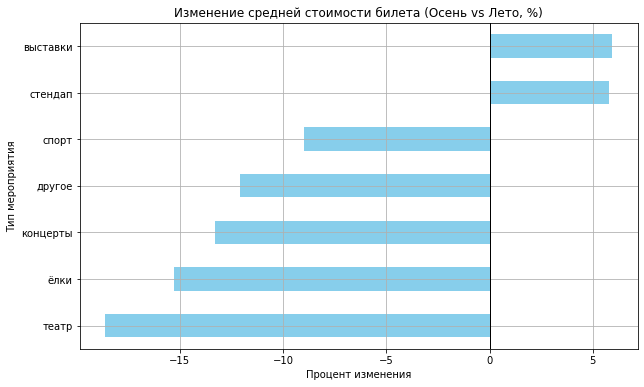

In [38]:
plot_data = ticket_price_change['change_pct'].sort_values()
plot_data.plot(kind='barh', figsize=(10, 6), color='skyblue', grid=True)
plt.title('Изменение средней стоимости билета (Осень vs Лето, %)')
plt.xlabel('Процент изменения')
plt.ylabel('Тип мероприятия')
plt.axvline(0, color='black', linewidth=1)
plt.show()

**Промежуточный вывод по анализу распределения заказов по сегментам и их сезонные изменения**

**1. Динамика заказов**

- Наблюдается устойчивый рост интереса к сервису: от июня (11.7% заказов) до пикового октября (35.1%).
- Суммарно осенние месяцы (сентябрь и октябрь) генерируют почти 60% всего объема заказов за изученный период. Это подтверждает гипотезу о сильной сезонности спроса.

**2. Изменение популярности мероприятий**

- Театр и Спорт — главные хиты осени. Доля спортивных мероприятий показала самый резкий рост (+8.76 п.п.), а театральных — (+4.65 п.п.).
- Концерты остаются лидером, однако их доля в общем портфеле заказов заметно снизилась (на 6.51 п.п.). Похожая ситуация наблюдается в категории «Другое». 

**3. Аудитория и устройства**
- Доминирование Mobile: Около 80% заказов совершается с мобильных устройств. Осенью наметился незначительный тренд к росту доли Desktop (+1.28 п.п.), что может быть связано с началом рабочего и учебного сезона.
- Сдвиг в возрастных категориях: Категория «0+» выросла на 5.27 п.п. Это коррелирует с началом учебного года и ростом популярности семейных мероприятий. Категория «18+», напротив, потеряла 3.4 п.п.

**4. Cредняя стоимость билета**
- Несмотря на рост общего числа заказов, средняя стоимость одного билета в ключевых категориях упала. Самое значительное снижение цены зафиксировано в категориях Театр (-18.6%) и Концерты (-13.3%).

**Вывод:** Общий рост выручки осенью, скорее всего, обусловлен масштабом, в то время как средний чек падает из-за снижения цен на билеты в самых массовых категориях или смещения интереса в сторону более бюджетных событий.

### Анализ осенней активности пользователей

Проанализируем динамику изменений по дням для:
- общего числа заказов;
- количества активных пользователей DAU;
- среднего числа заказов на одного пользователя;
- средней стоимости одного билета.

In [39]:
# Оставляем только осенние данные
autumn_df = df[df['season'] == 'осень'].copy()

# Создаем сводную таблицу по дням
daily_activity = autumn_df.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
)

# Рассчитываем среднее число заказов на одного пользователя
daily_activity['orders_per_user'] = daily_activity['total_orders'] / daily_activity['dau']

# Выводим первые строки
print("Ежедневная активность пользователей (сентябрь-октябрь 2024):")
display(daily_activity.head())

Ежедневная активность пользователей (сентябрь-октябрь 2024):


,total_orders,dau,avg_ticket_price,orders_per_user
created_dt_msk,,,,
2024-09-01,1314,555,202.149068,2.367568
2024-09-02,1370,571,190.847822,2.399299
2024-09-03,5090,776,80.713513,6.559278
2024-09-04,1757,683,179.598095,2.572474
2024-09-05,1936,738,190.156540,2.623306


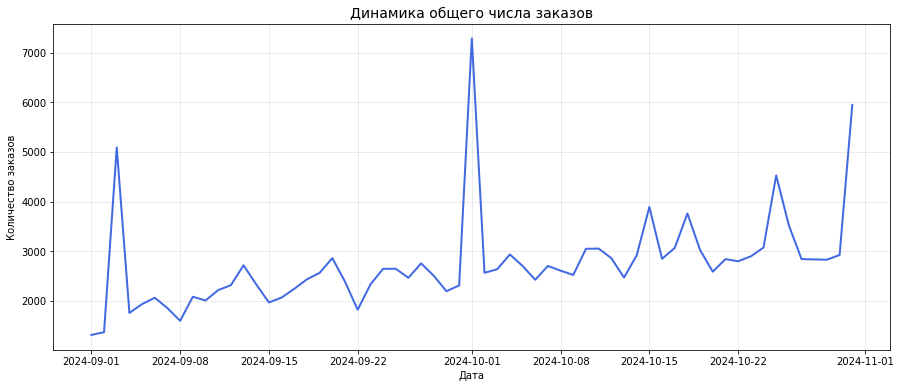

In [40]:
plt.figure(figsize=(15, 6))
plt.plot(daily_activity.index, daily_activity['total_orders'], color='royalblue', linewidth=2)

plt.title('Динамика общего числа заказов', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.show()

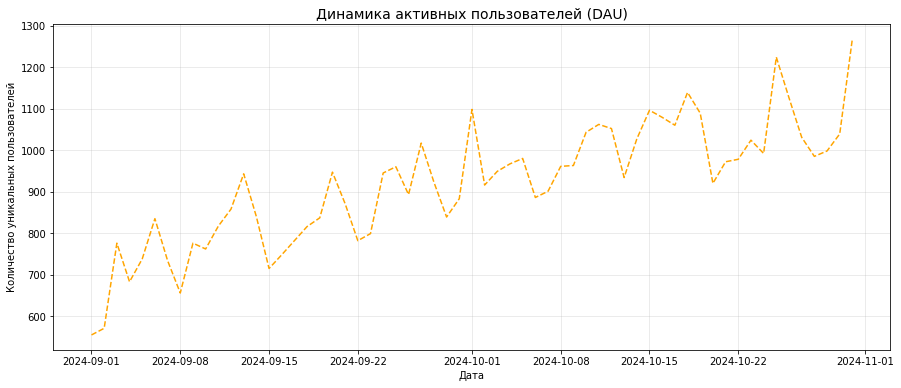

In [41]:
plt.figure(figsize=(15, 6))
plt.plot(daily_activity.index, daily_activity['dau'], color='orange', linestyle='--')

plt.title('Динамика активных пользователей (DAU)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей')
plt.grid(True, alpha=0.3)
plt.show()

На графике видно, что количество активных пользователей (DAU) имеет тренд роста к концу октября. 
Количество заказов демонстрирует резкие всплески (особенно 3 сентября и 1 октября). Вероятно, это связано со стартом продаж крупных мероприятий или проведением маркетинговых акций.

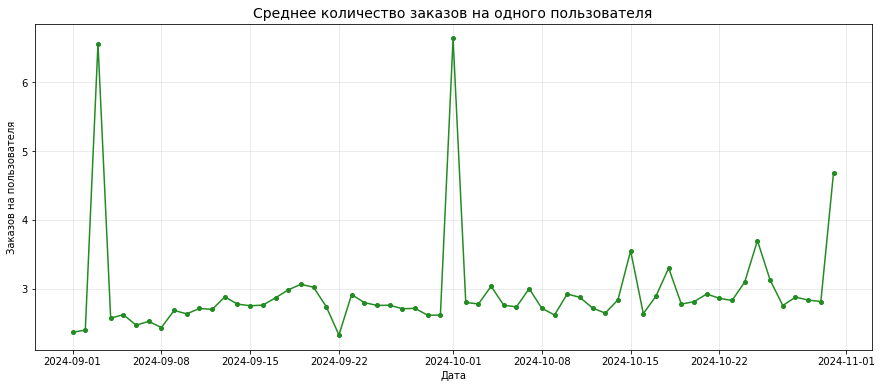

In [42]:
plt.figure(figsize=(15, 6))
plt.plot(daily_activity.index, daily_activity['orders_per_user'], color='forestgreen', marker='o', markersize=4)

plt.title('Среднее количество заказов на одного пользователя', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Заказов на пользователя')
plt.grid(True, alpha=0.3)
plt.show()

В обычные дни пользователь совершает в среднем 2.5–3 заказа. Однако мы видим два гигантских пика — в начале сентября и 1 октября, когда показатель взлетает до 6.5+ заказов на одного активного пользователя.

В эти даты пользователи покупали билеты сразу на несколько разных событий или на группу. Стоит проверить, не было ли в эти дни технических сбоев или специфических акций, так как поведение сильно выбивается из стандартного.

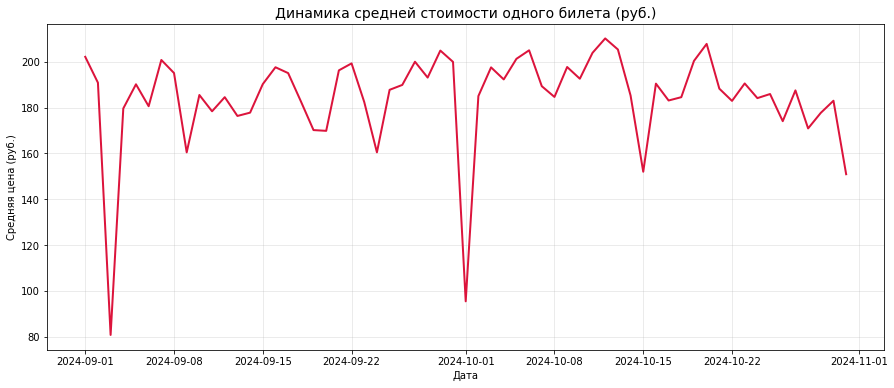

In [43]:
plt.figure(figsize=(15, 6))
plt.plot(daily_activity.index, daily_activity['avg_ticket_price'], color='crimson', linewidth=2)

plt.title('Динамика средней стоимости одного билета (руб.)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Средняя цена (руб.)')
plt.grid(True, alpha=0.3)
plt.show()

Средняя цена билета колеблется в диапазоне 160–210 рублей. Но в даты пиковых продаж (начало сентября и 1 октября) средняя стоимость билета падает до критических 80–95 рублей.

Резкий рост количества заказов осенью скорее всего, был обеспечен именно за счет дешевых билетов. Либо это были бюджетные мероприятия, либо огромные скидки. Именно поэтому общее число чеков выросло, а средний чек пошел вниз — люди покупали много, но очень дешево.

**Изучим недельную цикличность.** 

Выделим день недели и сравним пользовательскую активность в будни и выходные.

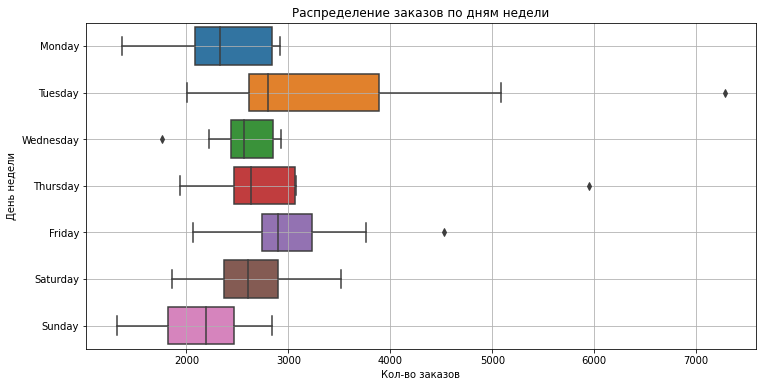

In [44]:
# Недельная цикличность
autumn_df['day_of_week'] = autumn_df['created_dt_msk'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=autumn_df.groupby(['created_dt_msk', 'day_of_week'])['order_id'].count().reset_index(),
    x='order_id',
    y='day_of_week',
    order=weekday_order
)

# Добавляем заголовок и метки оси
plt.title('Распределение заказов по дням недели')
plt.xlabel('Кол-во заказов')
plt.ylabel('День недели')
plt.grid()
plt.show()

- **Пик активности в середине недели:** Медианное количество заказов в будни (вторник–пятница) оказывается выше, чем в воскресенье или понедельник. Это может говорить о том, что пользователи предпочитают планировать свой досуг заранее, совершая покупки в середине рабочей недели.
- **Вторник — день аномалий**: Вторник выделяется самым длинным хвостом и экстремальным выбросом. Вероятно, те самые пиковые даты, которые мы видели на линейном графике, выпали именно на вторник. В этот день активность пользователей максимально непредсказуема и может кратно превышать норму.
- Распределения для субботы и воскресенья выглядят более короткими. Это означает, что активность в выходные более предсказуема и стабильна: нет резких падений или гигантских всплесков.
- На графике видно, что к концу недели (четверг-пятница) медиана заказов и верхние границы распределения повышаются вверх. Пользователи массово бронируют места на ближайшие вечерние мероприятия.

**Промежуточный вывод о пользовательской активности и недельной цикличности**

- На фоне стабильного уровня уникальных пользователей (DAU) зафиксированы мощные всплески заказов в начале сентября и октября (пик приходится на вторник 01.10). В эти даты активность возрастает не за счет притока новых людей, а за счет аномального поведения текущих: количество заказов на одного пользователя взлетает до 6.5+ (при норме 2.5–3).

- Обратная корреляция объема и цены: В дни пиковых продаж средняя цена билета падает более чем в 2 раза (до 80–95 руб.). Это подтверждает гипотезу о том, что рост выручки осенью обеспечен массовостью дешевых сегментов или масштабными акциями, а не увеличением маржинальности.

- Пользователи предпочитают планировать досуг заранее. Пик медианных заказов приходится на вторник–четверг, а к пятнице наблюдается подготовка к выходным. Выходные дни (суббота и воскресенье) характеризуются самой высокой стабильностью и предсказуемостью спроса, но лишены взрывного роста, как по будням.

### Анализ популярных событий и партнёров

In [45]:
#Анализ регионов
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count')
).sort_values(by='total_orders', ascending=False)

# Считаем доли
total_unique_events = df['event_id'].nunique()
total_orders_all = len(df)

region_stats['events_share_pct'] = (region_stats['unique_events'] / total_unique_events * 100).round(2)
region_stats['orders_share_pct'] = (region_stats['total_orders'] / total_orders_all * 100).round(2)

print("Топ-10 регионов по количеству заказов и разнообразию событий:")
display(region_stats.head(10))

Топ-10 регионов по количеству заказов и разнообразию событий:


,unique_events,total_orders,events_share_pct,orders_share_pct
region_name,,,,
Каменевский регион,5793,85377,26.33,30.31
Североярская область,3774,43473,17.15,15.43
Широковская область,1217,16082,5.53,5.71
Медовская область,462,13581,2.10,4.82
Озернинский край,349,10403,1.59,3.69
Светополянский округ,1059,7462,4.81,2.65
Малиновоярский округ,165,6314,0.75,2.24
Речиновская область,701,6264,3.19,2.22
Солнечноземская область,520,6234,2.36,2.21


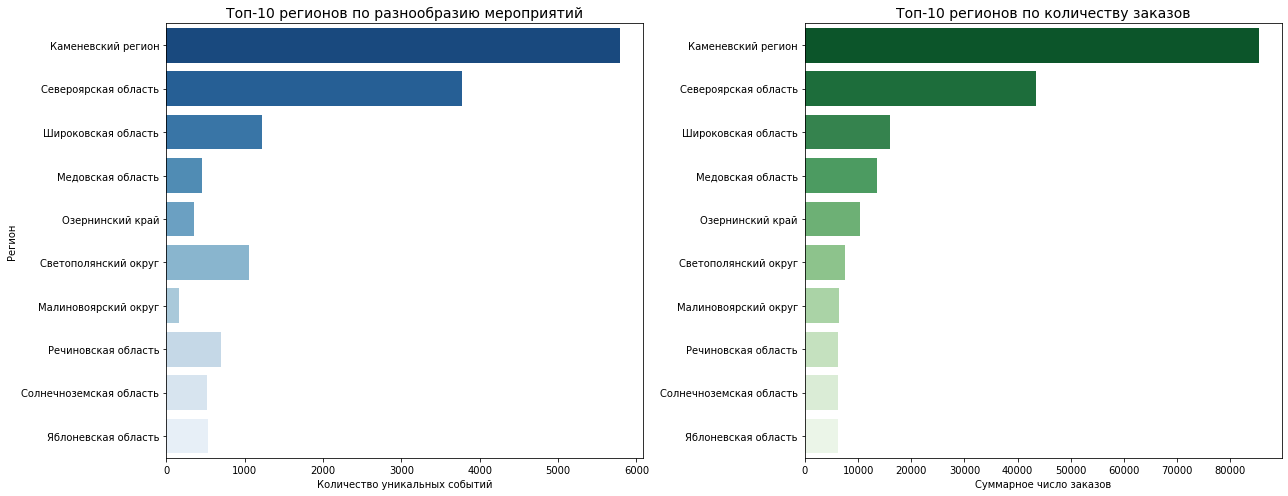

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Топ регионов по числу мероприятий (Разнообразие)
sns.barplot(data=region_stats.head(10).reset_index(), x='unique_events', y='region_name', ax=axes[0], palette='Blues_r')
axes[0].set_title('Топ-10 регионов по разнообразию мероприятий', fontsize=14)
axes[0].set_xlabel('Количество уникальных событий')
axes[0].set_ylabel('Регион')

#Топ регионов по количеству заказов (Спрос)
sns.barplot(data=region_stats.head(10).reset_index(), x='total_orders', y='region_name', ax=axes[1], palette='Greens_r')
axes[1].set_title('Топ-10 регионов по количеству заказов', fontsize=14)
axes[1].set_xlabel('Суммарное число заказов')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [47]:
# Анализ билетных партнёров
partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).sort_values(by='total_revenue', ascending=False)

# Считаем доли
partner_stats['revenue_share_pct'] = (partner_stats['total_revenue'] / df['revenue_rub'].sum() * 100).round(2)
partner_stats['orders_share_pct'] = (partner_stats['total_orders'] / total_orders_all * 100).round(2)

print("\nТоп-10 активных билетных партнёров:")
display(partner_stats.head(10))


Топ-10 активных билетных партнёров:


,unique_events,total_orders,total_revenue,revenue_share_pct,orders_share_pct
service_name,,,,,
Билеты без проблем,4015,57733,2.419824e+07,16.23,20.50
Мой билет,1293,34400,2.201605e+07,14.77,12.21
Облачко,2335,26402,1.858861e+07,12.47,9.37
Лови билет!,4813,40501,1.667564e+07,11.18,14.38
Весь в билетах,856,16426,1.653750e+07,11.09,5.83
Билеты в руки,3486,39792,1.319132e+07,8.85,14.13
Край билетов,252,6108,6.403469e+06,4.29,2.17
Прачечная,1026,10222,4.746811e+06,3.18,3.63
Дом культуры,272,4412,4.358656e+06,2.92,1.57


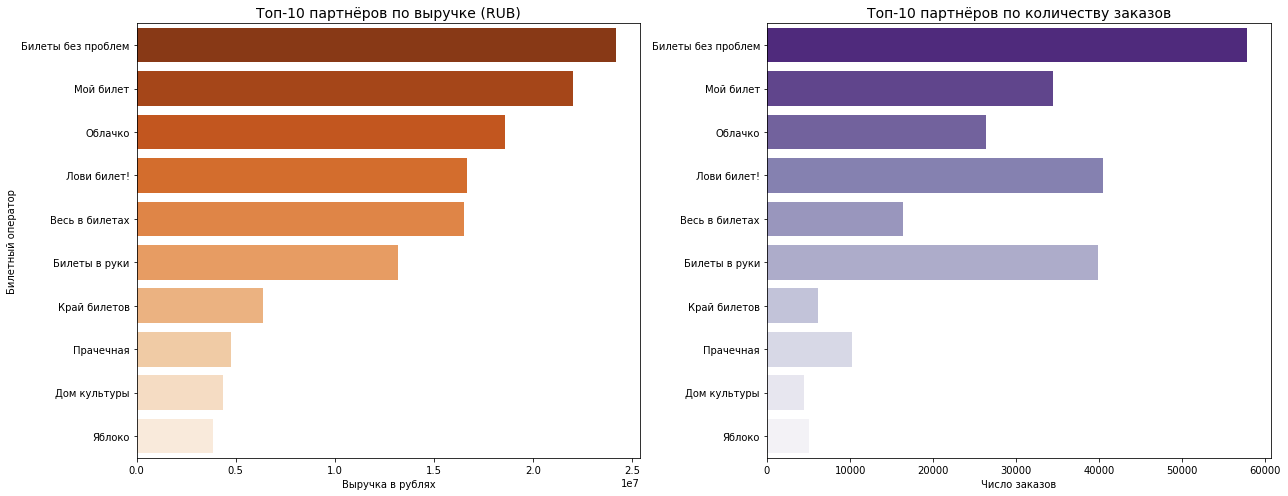

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Топ партнеров по выручке
sns.barplot(data=partner_stats.head(10).reset_index(), x='total_revenue', y='service_name', ax=axes[0], palette='Oranges_r')
axes[0].set_title('Топ-10 партнёров по выручке (RUB)', fontsize=14)
axes[0].set_xlabel('Выручка в рублях')
axes[0].set_ylabel('Билетный оператор')

# Топ партнеров по количеству заказов
sns.barplot(data=partner_stats.head(10).reset_index(), x='total_orders', y='service_name', ax=axes[1], palette='Purples_r')
axes[1].set_title('Топ-10 партнёров по количеству заказов', fontsize=14)
axes[1].set_xlabel('Число заказов')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Промежуточный вывод о популярных событиях и партнерах**
1. Регионы
- На рынке наблюдается сверхвысокая концентрация. Каменевский регион и Североярская область суммарно обеспечивают более 45% всех заказов.
- Каменевского регион - лидер. Его доля в заказах (30.3%) превышает его долю в количестве мероприятий (26.3%). Это говорит о том, что аудитория здесь максимально активна, а каждое событие привлекает больше покупателей, чем в среднем по стране.
- В Светополянском округе мы видим обратную картину: доля мероприятий (4.8%) почти в два раза выше доли заказов (2.6%). Регион перенасыщен событиями, которые не находят должного отклика у аудитории.

2. Билетные партнеры
- Сервис «Билеты без проблем» занимает первое место по всем ключевым метрикам: на него приходится каждый пятый проданный билет (20.5%) и более 16% всей выручки.
- «Лови билет!» — лидер массового сегмента. У этого партнера самый широкий ассортимент (более 4800 уникальных событий) и второе место по заказам, но лишь четвертое по выручке.
- «Весь в билетах» — несмотря на небольшое количество мероприятий (всего 856) и небольшую долю в заказах (5.8%), он приносит 11% выручки. Это означает, что средний чек здесь в несколько раз выше, чем у конкурентов.
- Топ-5 партнеров контролируют более 60% всей выручки сервиса. Это делает бизнес зависимым от отношений с этими партнерами.

Рост заказов осенью во многом обеспечен активностью в Каменевском регионе и  продажами массовых партнеров («Лови билет!»).


## Статистический анализ данных

**Гипотеза №1:** Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

$H_0$: Среднее количество заказов на одного пользователя мобильного приложения равно среднему количеству заказов пользователей стационарных устройств.

$H_1$: Среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств.

Критический уровень значимости: $\alpha = 0.05$.

In [49]:
# Подготовка выборок
mobile_orders = (
    autumn_df[autumn_df['device_type_canonical'] == 'mobile']
    .groupby('user_id')['order_id'].count()
)

desktop_orders = (
    autumn_df[autumn_df['device_type_canonical'] == 'desktop']
    .groupby('user_id')['order_id'].count()
)

In [50]:
print(f"Дисперсия Mobile: {mobile_orders.var():.3f}")
print(f"Дисперсия Desktop: {desktop_orders.var():.3f}")

Дисперсия Mobile: 4616.271
Дисперсия Desktop: 1281.247


In [51]:
n_mobile_h1 = len(mobile_orders)
n_desktop_h1 = len(desktop_orders)

print("Размеры выборок для статистического теста")
print(f"  - Mobile: {n_mobile_h1} чел.")
print(f"  - Desktop: {n_desktop_h1} чел.")
print(f"  - Соотношение: 1 к {n_mobile_h1 / n_desktop_h1:.1f}")

Размеры выборок для статистического теста
  - Mobile: 14105 чел.
  - Desktop: 4860 чел.
  - Соотношение: 1 к 2.9


Мы будем использовать тест Уэлча.

Потому что: 
- Выборка Mobile значительно больше Desktop.
- Разброс данных в группах различается.
- При таких объемах данных t-тест очень чувствителен и надежен.

In [52]:
alpha = 0.05
results = st.ttest_ind(mobile_orders, desktop_orders, equal_var=False, alternative='greater')

print(f"\nСреднее Mobile: {mobile_orders.mean():.3f}")
print(f"Среднее Desktop: {desktop_orders.mean():.3f}")
print(f"p-value: {results.pvalue}")

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу: среднее количество заказов у мобильных пользователей выше.")
else:
    print("Не получилось отвергнуть нулевую гипотезу.")


Среднее Mobile: 9.472
Среднее Desktop: 7.036
p-value: 0.0007670501698189077
Отвергаем нулевую гипотезу: среднее количество заказов у мобильных пользователей выше.


В ходе статистического анализа была проведена проверка гипотезы о различии в активности пользователей мобильных и стационарных устройств:
- Для проверки гипотезы использован тест Уэлча. Это позволило учесть всех пользователей (включая тех, кто использует обе платформы) и принять во внимание различие в дисперсиях и размерах выборок.

- Среднее количество заказов на мобильного пользователя (9.47) выше, чем у пользователя десктопа (7.04). Полученное p-value (0.0007) значительно ниже уровня значимости 0.05.

**Гипотеза подтвердилась.** Пользователи мобильного приложения демонстрируют более высокую активность. Это подтверждает важность развития мобильного направления и может служить обоснованием для приоритизации фичей именно в мобильном приложении, так как его аудитория приносит больше заказов на одного клиента.

**Гипотеза №2:** Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

$H_0$: Среднее время между заказами пользователей мобильных приложений и стационарных устройств равно.

$H_1$: Среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств.

In [54]:
# Подготовка выборок
mobile_days = autumn_df[
    (autumn_df['device_type_canonical'] == 'mobile') & 
    (autumn_df['days_since_prev'].notna())
]['days_since_prev']

desktop_days = autumn_df[
    (autumn_df['device_type_canonical'] == 'desktop') & 
    (autumn_df['days_since_prev'].notna())
]['days_since_prev']

In [55]:
n_mobile_h2 = len(mobile_days)
n_desktop_h2 = len(desktop_days)

print("Размеры выборок для статистического теста")
print(f"  - Mobile: {n_mobile_h2} наблюдений")
print(f"  - Desktop: {n_desktop_h2} наблюдений")


Размеры выборок для статистического теста
  - Mobile: 126675 наблюдений
  - Desktop: 32841 наблюдений


In [56]:
alpha = 0.05
results_days = st.ttest_ind(mobile_days, desktop_days, equal_var=False, alternative='greater')

print(f"Среднее время Mobile: {mobile_days.mean():.2f}")
print(f"Среднее время Desktop: {desktop_days.mean():.2f}")
print(f"p-value: {results_days.pvalue}")

if results_days.pvalue < alpha:
    print("Отвергаем нулевую гипотезу: интервал между заказами у мобильных пользователей больше (возвращаются реже).")
else:
    print("Не получилось отвергнуть нулевую гипотезу.")

Среднее время Mobile: 3.77
Среднее время Desktop: 3.03
p-value: 3.280160004483965e-22
Отвергаем нулевую гипотезу: интервал между заказами у мобильных пользователей больше (возвращаются реже).


В ходе проверки гипотезы о времени между повторными заказами были получены следующие результаты:
- Среднее время между заказами у мобильных пользователей составило 3.77 дня, а у пользователей стационарных устройств — 3.03 дня.
- Значение p-value (3.280160004483965e-22) позволяет отвергнуть нулевую гипотезу.
- Статистический анализ подтвердил, что в данной выборке пользователи десктопной версии возвращаются за повторной покупкой быстрее, чем пользователи мобильной версии (интервал меньше на 0.74 дня).

Это может быть связано с тем, что десктоп часто используется для рабочих/рутинных покупок билетов, в то время как мобильное приложение — для более редких, но объемных заказов (как показала Гипотеза №1).

## Общий вывод и рекомендации

**Обзор данных**


В рамках проекта был проведен исследовательский анализ данных сервиса «Яндекс Афиша» за период с 1 июня по 31 октября 2024 года.

- Исходные данные прошли полную предобработку: очистку от технических ошибок, удаление аномальных выбросов и унификацию валют.

- Итоговый объем данных для анализа составил 281 664 заказа, что обеспечило высокую достоверность результатов.

**Основные результаты анализа**
- Осень является ключевым периодом для сервиса, генерируя 60% годовых заказов (с пиком в октябре — 35%). Рост спроса сопровождается изменением предпочтений: резко вырос интерес к Спорту (+8.7 п.п.) и Театру (+4.6 п.п.), в то время как доля Концертов снизилась.

- Подтверждена причина снижения средней стоимости заказа осенью. Выручка растет за счет количества транзакций, а не их стоимости. В пиковые периоды средняя цена билета падала в 2 раза (до 80–95 руб.), особенно в категориях Театр (-18.6%) и Концерты (-13.3%).

- Выявлены аномальные всплески активности по вторникам (03.09 и 01.10). В эти дни количество заказов на одного пользователя возрастало до 6.5+, что указывает на проведение масштабных акций или старт продаж бюджетных линеек билетов.

**Регионы и лидеры рынка:**

- Каменевский регион — основной лидер выручки (30% всех заказов).

- Рынок высококонцентрирован. Сервис «Билеты без проблем» лидирует по выручке, а «Лови билет!» обеспечивает массовый охват за счет широкого ассортимента и низкого чека.

**Результаты проверки гипотез**


Статистический анализ (тест Уэлча):

- Гипотеза №1: Мобильные пользователи лидируют по количеству заказов на человека (9.47 против 7.04).

- Гипотеза №2: Десктопные пользователи имеют чуть более короткий цикл возврата (3.03 дня), хотя их общая активность ниже.

**Рекомендации**
- Приоритизация Mobile: Учитывая, что десктопные пользователи возвращаются быстрее, но покупают меньше, можно попробовать внедрить в мобильное приложение механику «быстрых напоминаний», чтобы сократить их интервал между покупками с 3.7 до уровня десктопа.

- Оптимизация региональной стратегии: В Светополянском округе наблюдается избыток предложений при низком спросе — рекомендуется снизить расходы на привлечение партнеров в этом регионе.

- В Каменевском регионе следует расширять ассортимент.

- Чтобы выровнять тренд на снижение рседнего чека, рекомендуется внедрять механики рекомендаци именно в периоды массовых распродаж бюджетных билетов.

- Необходимо ументшить риски, так как зависимость от топ-5 партнеров (60% выручки) критична. Стоит обратить внимание на развитие премиальных партнеров типа «Весь в билетах» для роста маржинальности в осенний период.